In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Actor-Critic

The learned baseline of the last two sections still has a Monte Carlo problem. The weight $\hat{G}_t - \hat{V}(s_t)$ needs the reward-to-go $\hat{G}_t$, and the robot only knows $\hat{G}_t$ after the episode has ended, with every coin flip of the remaining trajectory baked into it. In this section we replace the sampled tail of the trajectory by an estimate, borrowing the bootstrapped one-step target that Q-Learning of that section built its update on. The result is a pair of learners that improve each other as the robot acts: an *actor*, the policy $\pi_\theta$, and a *critic*, the value estimate $\hat{V}$. The arrangement goes back to @Barto.Sutton.Anderson.1983, long before deep learning; a convergence analysis is given by @Konda.Tsitsiklis.2000 .

## Bootstrapping the Reward-to-Go

Write out what the reward-to-go contains,

$$\hat{G}_t = r_t + \gamma\, \hat{G}_{t+1},$$

and recall that $\hat{G}_{t+1}$ is exactly the quantity that $\hat{V}(s_{t+1})$ is being trained to predict. So instead of waiting for the sampled value of $\hat{G}_{t+1}$, substitute the prediction:

$$\hat{G}_t \approx r_t + \gamma\, \hat{V}(s_{t+1}).$$

The weight on the score at step $t$ was $\hat{G}_t - \hat{V}(s_t)$ in that section; after the substitution it becomes

$$\delta_t = r_t + \gamma\, \hat{V}(s_{t+1}) - \hat{V}(s_t),$$

with the convention $\hat{V}(s_{t+1}) = 0$ when $s_{t+1}$ is terminal, for the same reason as in that section. This quantity is called the temporal-difference error, TD error for short: the difference between what one step actually produced, $r_t + \gamma \hat{V}(s_{t+1})$, and what the critic predicted, $\hat{V}(s_t)$.

The TD error also carries the right meaning for our purpose. Suppose for a moment that the critic were exact, $\hat{V} = V^{\pi}$. Taking the expectation of the equation over the next state gives

$$E\big[ \delta_t \mid s_t, a_t \big] = r(s_t, a_t) + \gamma \sum_{s'} P(s' \mid s_t, a_t)\, V^{\pi}(s') - V^{\pi}(s_t) = Q^{\pi}(s_t, a_t) - V^{\pi}(s_t),$$

where the first equality writes the expectation over the next state using the transition function, and the second is the equation written with $V^\pi$. The right-hand side compares the value of taking action $a_t$ at $s_t$ against the value of $s_t$ itself: the advantage of the action, the same quantity that the learned baseline of that section estimated with $\hat{G}_t - \hat{V}(s_t)$. A single transition, one reward plus one critic evaluation, gives an unbiased one-sample estimate of the advantage. Compare that with $\hat{G}_t - \hat{V}(s_t)$, which needed the entire remaining trajectory.

There's no free lunch here, and it is the same lunch that Q-Learning paid for. During training $\hat{V}$ is not $V^\pi$, so $\delta_t$ is a biased estimate of the advantage, and the policy update below is no longer an unbiased gradient of $J(\theta)$. We traded variance for bias. The trade is usually worth it: the variance of the Monte Carlo tail grows with the horizon, while the bias shrinks as the critic improves.

## The Actor-Critic Algorithm

Both learners now update from the same TD error. Writing $\hat{V}_w$ for a critic with parameters $w$, whether a table or a network, the updates after observing the transition $(s_t, a_t, r_t, s_{t+1})$ are

$$w \leftarrow w + \alpha_w\, \delta_t\, \nabla_w \hat{V}_w(s_t), \qquad \theta \leftarrow \theta + \alpha_\theta\, \delta_t\, \nabla_\theta \log \pi_\theta(a_t \mid s_t).$$

The critic update is a semi-gradient step that moves $\hat{V}_w(s_t)$ toward the one-step target $r_t + \gamma \hat{V}_w(s_{t+1})$, exactly as Q-Learning in that section moves $\hat{Q}(s_t, a_t)$ toward its bootstrapped target; with a table, $\nabla_w \hat{V}_w(s_t)$ is an indicator of the single entry $s_t$ and the update reads $\hat{V}(s_t) \leftarrow \hat{V}(s_t) + \alpha_w \delta_t$. The actor update is the policy gradient step of that section with $\delta_t$ as the advantage weight. As in the previous sections we drop the $\gamma^t$ factor that the strict derivation would place in front of the actor update; Sutton and Barto's boxed one-step actor-critic keeps it, through a running factor updated as $I \leftarrow \gamma I$, and we follow implementation practice instead.

Note that the weight $\delta_t$ needs only the single transition $(s_t, a_t, r_t, s_{t+1})$, so the equation can be applied at every step of the episode as the robot acts, the way Q-Learning updates its table. Nothing needs to terminate before learning starts, which also means the method extends to tasks that never end. REINFORCE, with or without a baseline, cannot say the same: its weight waits for the episode's tail.

Two learning rates appear because the two learners have different jobs. The critic chases a moving target twice over: every actor update changes the policy, which changes the values the critic is trying to predict, and every critic update moves the bootstrapped targets themselves. The actor then judges its actions with whatever the critic currently believes. If the actor moves much faster than the critic, the advantages are judged against stale values and the updates degrade. The practical rule is to let the critic learn faster than the actor, either through a larger learning rate or through more update steps, and our implementation uses the second form.

## Implementation on CartPole

We stay on CartPole with the networks of that section. The helpers change in one place: the batch must now carry each transition's reward, next state, and termination flag, because the TD error consumes transitions rather than trajectories.

In [1]:

%matplotlib inline
import numpy as np
import torch
from torch import nn
import gymnasium as gym
from d2l import torch as d2l

gamma = 0.99  # Discount factor
num_updates = 150  # Gradient updates per training run
batch_size = 8  # Episodes per update
num_seeds = 3  # Independent runs per algorithm
critic_steps = 20  # Critic regression passes per batch

def make_nets():
    policy = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 2))
    value = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 1))
    return policy, value

def sample_episode(env, policy):
    state, _ = env.reset()
    S, A, R, S2, T = [], [], [], [], []
    done = False
    while not done:
        S.append(state)
        probs = torch.softmax(policy(torch.tensor(state)), dim=-1)
        action = torch.multinomial(probs, 1).item()
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        A.append(action)
        R.append(reward)
        S2.append(state)
        T.append(float(terminated))
    return S, A, R, S2, T

def reward_to_go(rewards):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    return out[::-1]

def collect(env, policy):
    S, A, R, S2, T, G, returns = [], [], [], [], [], [], []
    for _ in range(batch_size):
        s, a, r, s2, t = sample_episode(env, policy)
        returns.append(sum(r))
        S += s; A += a; R += r; S2 += s2; T += t
        G += reward_to_go(r)
    return (torch.tensor(np.array(S)), torch.tensor(A),
            torch.tensor(R, dtype=torch.float32),
            torch.tensor(np.array(S2)), torch.tensor(T),
            torch.tensor(G), np.mean(returns))

def setup(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    env = gym.make('CartPole-v1')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    policy, value = make_nets()
    opt_policy = torch.optim.Adam(policy.parameters(), lr=1e-2)
    opt_value = torch.optim.Adam(value.parameters(), lr=1e-2)
    return env, policy, value, opt_policy, opt_value

def policy_step(policy, opt_policy, S, A, adv):
    logp = torch.log_softmax(policy(S), dim=-1)
    logp = logp.gather(1, A[:, None]).squeeze(-1)
    loss = -(adv * logp).mean()
    opt_policy.zero_grad()
    loss.backward()
    opt_policy.step()

def value_step(value, opt_value, S, target):
    loss = ((value(S).squeeze(-1) - target) ** 2).mean()
    opt_value.zero_grad()
    loss.backward()
    opt_value.step()

The Monte Carlo reference point is `train_reinforce` from that section, repeated here with the shared helpers so both methods run under identical conditions:

In [2]:

def train_reinforce(seed):
    env, policy, value, opt_policy, opt_value = setup(seed)
    curve = []
    for it in range(num_updates):
        S, A, R, S2, T, G, avg_return = collect(env, policy)
        curve.append(avg_return)
        adv = G - value(S).squeeze(-1).detach()
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        policy_step(policy, opt_policy, S, A, adv)
        # Critic: regression on the Monte Carlo reward-to-go
        value_step(value, opt_value, S, G)
    return np.array(curve)

Actor-critic differs in two lines and one habit. The advantage is the TD error of the equation instead of $\hat{G}_t - \hat{V}(s_t)$, and the critic regresses on the bootstrapped one-step target instead of the reward-to-go. The habit is the two-timescale rule: the critic takes its `critic_steps` regression passes *before* the actor consumes the advantages, so the actions are judged by the freshest available critic rather than last batch's:

In [3]:

def train_ac(seed):
    env, policy, value, opt_policy, opt_value = setup(seed)
    curve = []
    for it in range(num_updates):
        S, A, R, S2, T, G, avg_return = collect(env, policy)
        curve.append(avg_return)
        # Critic first: fit toward the bootstrapped one-step target
        for _ in range(critic_steps):
            with torch.no_grad():
                y = R + gamma * (1 - T) * value(S2).squeeze(-1)
            value_step(value, opt_value, S, y)
        # TD error as the advantage, from the updated critic
        with torch.no_grad():
            adv = (R + gamma * (1 - T) * value(S2).squeeze(-1)
                   - value(S).squeeze(-1))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        policy_step(policy, opt_policy, S, A, adv)
    return np.array(curve)

We run both for 150 updates of 8 episodes each, three seeds apiece:

REINFORCE + baseline: mean return over the last 10 updates = 475


actor-critic: mean return over the last 10 updates = 489


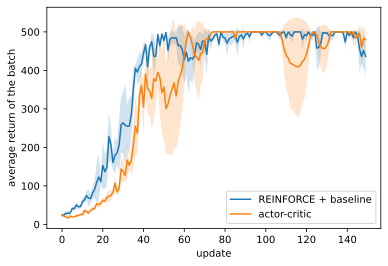

In [4]:

d2l.compare_agents({'REINFORCE + baseline': train_reinforce,
                    'actor-critic': train_ac}, num_seeds)

The two curves are the bias-variance trade drawn by the algorithms themselves. Actor-critic starts slower: for its first stretch the critic is still wrong, the TD errors point in poorly chosen directions, and the biased updates buy little. REINFORCE is faster out of the gate because its Monte Carlo weight is correct on average from the first batch. Then the roles reverse. Once the critic has caught up, the actor-critic runs settle onto the 500 ceiling, and every seed spends the final ten updates exactly there, while the Monte Carlo curve keeps dipping and recovering to the end: its advantage estimates still carry the sampled noise of every remaining coin flip of the trajectory, and a run at the ceiling is only ever one noisy batch away from a stumble. The early cost is the bias while the critic trains, the late payoff is the variance that left with the Monte Carlo tail, and both halves of the bargain from the theory are visible in one figure.

## Summary

Actor-critic replaces the sampled reward-to-go in the policy gradient with a bootstrapped one-step estimate. The TD error $\delta_t = r_t + \gamma \hat{V}(s_{t+1}) - \hat{V}(s_t)$ is, in expectation under an exact critic, the advantage of the action taken, so it can serve as the weight on the score function. The actor is the policy, the critic is the value network, and the weight consumes single transitions rather than trajectory tails, so updates need not wait for episodes to end. The critic introduces bias while it is still wrong, in exchange for removing the variance of the Monte Carlo tail; this is the same bargain Q-Learning struck, now on the policy side. On CartPole the bargain is visible in the learning curves: actor-critic trails while its critic trains, then holds the ceiling with a steadiness that the Monte Carlo method never reaches. The critic must also learn faster than the actor, which our implementation arranges by giving it multiple regression passes per batch, taken before the actor uses the advantages.

## Exercises

1. Sweep `critic_steps` over $\{1, 5, 20, 50\}$ with a few seeds per setting. Where does the algorithm fail, and how does the failure connect to the two-timescale rule?
1. Replace the one-step target in the equation by a three-step target $r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \gamma^3 \hat{V}(s_{t+3})$. What does this do to bias and variance, and where do the two extremes of this family land?
1. The actor update in the equation is biased whenever $\hat{V} \neq V^{\pi_\theta}$. Explain why the baseline argument of that section, which allowed any $b(s_t)$ without bias, does not cover the bootstrapped weight $\delta_t$.
1. the equation can be applied at every single transition, with no batch at all. Implement this fully online variant on CartPole and compare it with the batched version. What goes wrong, and which ingredient of that section's recipe would address it?